<a href="https://colab.research.google.com/github/sdtasneem/AIDS-Projects/blob/main/Telco_Customer_Churn_ANN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import the main libraries used for data analysis, visualization, and deep learning.
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Import Keras components used to construct the Artificial Neural Network (ANN).
from tensorflow import keras
from tensorflow.keras import layers, models

In [ ]:
# Import scikit-learn tools for feature selection, scaling, and train-test splitting.
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [ ]:
# Store the raw GitHub URL of the IBM Telco Customer Churn dataset.
url="https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"


In [ ]:
# Load the dataset directly from the public CSV URL into a pandas DataFrame.
df=pd.read_csv(url)

In [ ]:
# Display the first five rows to understand the structure and values in the dataset.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Display all DataFrame columns
pd.set_option("display.max_columns",None)

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
# Check column names, data types, and the number of non-null values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Check the distribution of customers by gender.
df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


In [ ]:
# Convert TotalCharges to numeric; invalid values are converted to NaN.
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
# Encode gender as 1 for Female and 0 for Male.
df['gender']=pd.to_numeric(df['gender'].map({"Female":1,"Male":0}))
# Encode the target variable Churn as 1 for Yes and 0 for No.
df['Churn']=pd.to_numeric(df['Churn'].map({"Yes":1,"No":0}))

In [ ]:
# Verify the updated data types after the conversions above.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Identify missing values in each column.
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# We are dropping any rows that have missing values, updating the DataFrame directly.
df.dropna(inplace=True)

In [ ]:
# Just listing all the column names for easy reference.
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Define the initial set of customer attributes considered for model training.
numerical_features=['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [ ]:
# Remove duplicate customer records from the dataset.
df.drop_duplicates(inplace=True)

In [ ]:
# Confirm that no missing values remain after cleaning.
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Convert remaining categorical feature columns to numeric factor codes.
# Keep only feature names that are still present in the DataFrame.
for col in numerical_features:
  if df[col].dtype==object:
    df[col]=pd.factorize(df[col])[0]
numerical_features=[c for c in numerical_features  if c in df.columns ]
numerical_features

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [ ]:
# Separate the input features (X) from the target variable (y).
# Churn is the binary target that the ANN will predict.
X=df[numerical_features]
y=df['Churn']

In [ ]:
# Create a Random Forest estimator and use Recursive Feature Elimination (RFE)
# to identify the five most useful features for the churn model.
rf=RandomForestClassifier(n_estimators=150,random_state=42)
rfe=RFE(estimator=rf,n_features_to_select=5)
rfe.fit(X,y)

RFE(estimator=RandomForestClassifier(n_estimators=150, random_state=42),
    n_features_to_select=5)

In [ ]:
# Extract the feature names selected by RFE.
selected_features=[f for f,s in zip(numerical_features,rfe.support_) if s] #zip is used to combine lists or dictionary into a tuple
print(selected_features) #rfe.support_:is a boolean mask(TRUE/FALSE)

['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges', 'TotalCharges']


In [ ]:
# Train the Random Forest and calculate feature importance scores.
# Sort the features from most important to least important.
rf.fit(X,y)
importances=pd.DataFrame({"features":numerical_features,"important":rf.feature_importances_})
importances=importances.sort_values('important',ascending=False)
print(importances)

            features  important
18      TotalCharges   0.189427
17    MonthlyCharges   0.180710
4             tenure   0.162059
14          Contract   0.077676
16     PaymentMethod   0.056681
8     OnlineSecurity   0.043676
11       TechSupport   0.038319
0             gender   0.026925
7    InternetService   0.024975
15  PaperlessBilling   0.024614
9       OnlineBackup   0.023989
10  DeviceProtection   0.023196
6      MultipleLines   0.022399
2            Partner   0.022115
1      SeniorCitizen   0.020578
12       StreamingTV   0.019852
13   StreamingMovies   0.019395
3         Dependents   0.019088
5       PhoneService   0.004327


<Axes: xlabel='important', ylabel='features'>

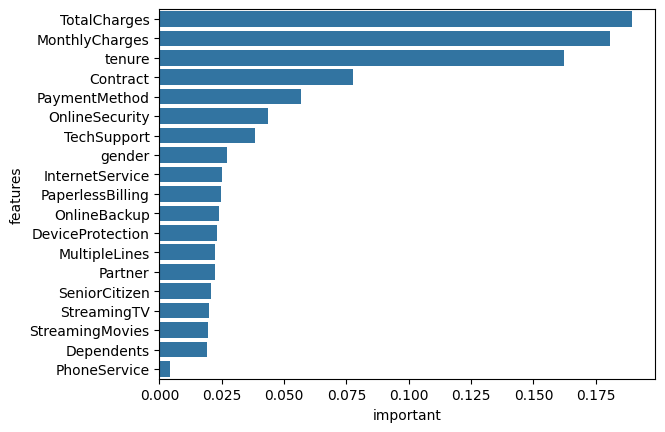

In [ ]:
# Visualize Random Forest feature importance to make the feature ranking easier to interpret.
sns.barplot(x='important',y='features',data=importances)

In [ ]:
# Reduce the input dataset to only the features selected by RFE.
X=df[selected_features]
y=df['Churn']

In [ ]:
# Split the data into training and testing sets.
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [ ]:
# Standardize the selected features so they have comparable scales.
# Fit the scaler only on training data to avoid data leakage.
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [ ]:
# Save the fitted scaler so the same preprocessing can be reused during prediction.
import pickle
with open('scaler.pkl',"wb") as f:
  pickle.dump(scaler,f)

In [ ]:
# Define the ANN architecture.
# When Keras Tuner provides hyperparameters, the architecture can be tuned.
# The output layer uses sigmoid because this is a binary classification problem.
# Binary cross-entropy is used as the loss function for binary classification.
def create_model(hp=None):
  if hp:
    model = models.Sequential()
    #input layer + hidden _ 1 created here
    model.add(layers.Dense(
        units =hp.Choice('units_1',values=[32,64,128]),
        activation = 'relu',
        input_shape = (x_train_scaled.shape[1],)
    ))

    if hp.Boolean('second_layer'):
      model.add(layers.Dense(
          units=hp.Choice('units_2',values=[16,32]),
          activation='relu'
      ))
    #output layer
    model.add(layers.Dense(1, activation='sigmoid'))

    #compile
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
  else:
    #default
    model = models.Sequential([
        layers.Dense(64, activation='relu',input_shape=(x_train_scaled.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1,activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy'])
  return model


In [ ]:
# Build the initial ANN using the default architecture and display its summary.
initial_model=create_model()
initial_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the initial ANN for up to 50 epochs using a validation split of 20%.
history=initial_model.fit(x_train_scaled,y_train,epochs=50,batch_size=32,validation_split=0.20)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7366 - loss: 0.5255 - val_accuracy: 0.7218 - val_loss: 0.4421
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7469 - loss: 0.4562 - val_accuracy: 0.7929 - val_loss: 0.4301
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7969 - loss: 0.4375 - val_accuracy: 0.7982 - val_loss: 0.4270
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7879 - loss: 0.4392 - val_accuracy: 0.7964 - val_loss: 0.4236
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7929 - loss: 0.4369 - val_accuracy: 0.7973 - val_loss: 0.4241
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8012 - loss: 0.4287 - val_accuracy: 0.7991 - val_loss: 0.4183
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7946 - loss: 0.4374 - val_accuracy: 0.7956 - val_loss: 0.4210
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7988 - loss: 0.4228 - val_accuracy: 0.

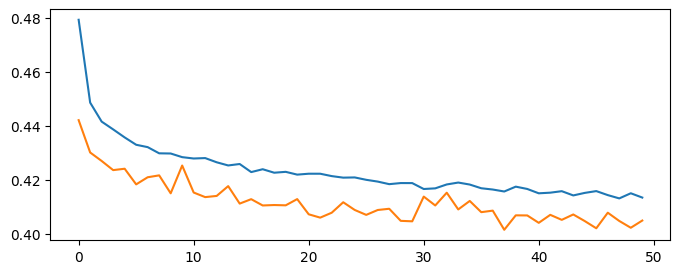

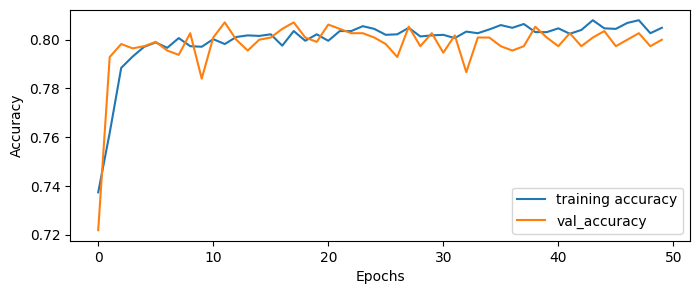

In [ ]:
# Plot training and validation loss to monitor model learning.
# Plot training and validation accuracy to compare model performance over epochs.
plt.figure(figsize=(8,3))
plt.plot(history.history['loss'],label='training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.show()

plt.figure(figsize=(8,3))
plt.plot(history.history['accuracy'],label='training accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [ ]:
# Evaluate the initial ANN on the unseen test set.
loss,accuracy=initial_model.evaluate(x_test_scaled,y_test)
print(f'loss:{loss} and accuracy:{accuracy}')

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7879 - loss: 0.4412
loss:0.450107216835022 and accuracy:0.7867803573608398


In [ ]:
!pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

In [ ]:
# Configure RandomSearch to find an ANN configuration with the best validation accuracy.
# Five different hyperparameter combinations will be tested.
tuner=kt.RandomSearch(
    create_model,
    objective='val_accuracy',
    max_trials=5,
    directory='keras_tuning',
    project_name='churn prediction'

)

In [ ]:
# Stop training when validation loss stops improving for five consecutive epochs.
stop_early=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5)

In [ ]:
tuner.search(
    x_train_scaled,
    y_train,
    epochs=20,
    validation_split=0.20,
    callbacks=[stop_early]
)

Trial 5 Complete [00h 00m 24s]
val_accuracy: 0.8071110844612122

Best val_accuracy So Far: 0.8133333325386047
Total elapsed time: 00h 01m 25s


In [ ]:
# Run the hyperparameter search using the scaled training data.
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hps)
for p in best_hps.values:
  print(f'{p}:{best_hps.get(p)}')

units_1:32
second_layer:True
units_2:32


In [ ]:
# Retrieve the best hyperparameter configuration found by Keras Tuner.
# Print each selected hyperparameter and its value.
best_model=tuner.hypermodel.build(best_hps)


In [ ]:
# Train the tuned ANN model and keep a validation split for monitoring performance.
best_history = best_model.fit(
    x_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6251 - loss: 0.6158 - val_accuracy: 0.7929 - val_loss: 0.4358
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7815 - loss: 0.4463 - val_accuracy: 0.7991 - val_loss: 0.4194
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7726 - loss: 0.4551 - val_accuracy: 0.8018 - val_loss: 0.4131
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7930 - loss: 0.4236 - val_accuracy: 0.7938 - val_loss: 0.4085
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7845 - loss: 0.4316 - val_accuracy: 0.7920 - val_loss: 0.4131
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7906 - loss: 0.4275 - val_accuracy: 0.8062 - val_loss: 0.4081
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7891 - loss: 0.4408 - val_accuracy: 0.8080 - val_loss: 0.4051
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7830 - loss: 0.4315 - val_accuracy: 0

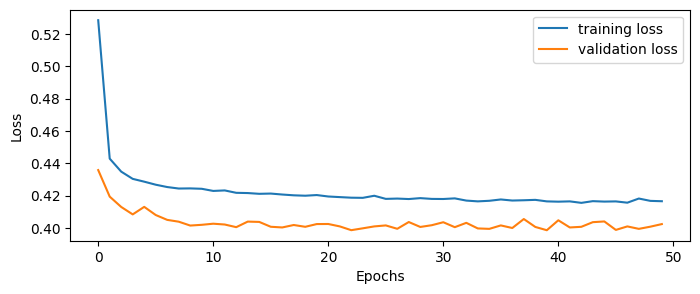

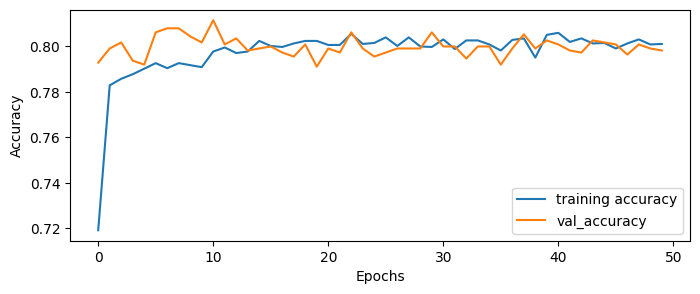

In [ ]:
# Plot loss and accuracy curves for the tuned ANN model.
plt.figure(figsize=(8,3))
plt.plot(best_history.history['loss'],label='training loss')
plt.plot(best_history.history['val_loss'],label='validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()


plt.figure(figsize=(8,3))
plt.plot(best_history.history['accuracy'],label='training accuracy')
plt.plot(best_history.history['val_accuracy'],label='val_accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [ ]:
# Evaluate the tuned ANN on the unseen test set and report its loss and accuracy.
best_loss,best_accuracy=best_model.evaluate(x_test_scaled,y_test)
print(f'best model loss:{best_loss}')
print(f'best model accuracy:{best_accuracy}')

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7830 - loss: 0.4373
best model loss:0.4434047043323517
best model accuracy:0.7867803573608398


In [ ]:
# Save the trained ANN model and the selected feature list for future predictions.
best_model.save('best_churn_prediction.h5')
with open("selected_features.pkl","wb") as f:
  pickle.dump(selected_features,f)

In [ ]:
# Load the saved ANN model, scaler, and selected feature names.
# These objects are required to reproduce the same prediction pipeline.
def load_model_components():
  model=tf.keras.models.load_model('best_churn_prediction.h5')
  with open('scaler.pkl','rb') as f:
    scaler=pickle.load(f)
  with open('selected_features.pkl','rb') as f:
    selected_features=pickle.load(f)
  return model,scaler,selected_features

In [ ]:
# Create a reusable function that accepts customer feature values and predicts churn.
# The input is scaled using the saved scaler before being passed to the ANN.
# A probability above 0.50 is classified as customer churn.
def predict_churn(*args):
  model, scaler, selected_features = load_model_components()
  input_data = pd.DataFrame([args], columns=selected_features)
  input_scaled = scaler.transform(input_data)
  prediction = model.predict(input_scaled)[0][0]
  print(f"prediction : {prediction}")
  probability = float(prediction)
  churn_status = "Yes" if probability > 0.50 else "No"

  return {
      "Churn Probability":probability,
      "Will Customer Churn":churn_status
  }

In [ ]:
# Example prediction using five input values in the same order as selected_features.
# The function returns both churn probability and the predicted churn status.
predict_churn(34, 1, 1, 56.96, 1900)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
prediction : 0.06553033739328384


{'Churn Probability': 0.06553033739328384, 'Will Customer Churn': 'No'}